# Benchmark SMC assignation v2

Ce notebook implémente un benchmark reproductible avec:
- repetition multi-seeds,
- deux regimes (`cold_full`, `warm_smart`),
- decomposition du temps (`matrices`, `opti/approx`, `eval distance`, `global`, `pre-eval`),
- export des resultats bruts + agreges,
- visualisations cout/qualite (barres empilees, Pareto, scaling).

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd()
for _ in range(5):
    if (ROOT / "permabc").is_dir():
        break
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from jax import random

try:
    import pandas as pd
except Exception:
    pd = None

from permabc.models.Gaussian_with_no_summary_stats import GaussianWithNoSummaryStats
from permabc.algorithms.vanilla import abc_vanilla, perm_abc_vanilla
from permabc.core.distances import (
    optimal_index_distance,
    compute_total_distance,
    compute_distances_with_current_assignment,
    swap_refine_numba,
)
from permabc.core.lsa import solve_lsa, solve_lsa_custom
from permabc.core.hilbert import hilbert_distance_cgal
from permabc.core.kernels import KernelTruncatedRW, KernelRW
from permabc.utils.functions import Theta

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True
print("Python:", sys.executable)
print("ROOT:", ROOT)

Python: /Users/antoineluciano/.pyenv/versions/3.10.13/envs/permabc/bin/python
ROOT: /Users/antoineluciano/Documents/Recherche/permABC


In [2]:
# ---- Parametres benchmark ----
QUICK_MODE = False

if QUICK_MODE:
    SEEDS = [0, 1]
    K_LIST = [10, 20]
    N_PARTICLES_LIST = [400]
    N_OBS_LIST = [10]
else:
    SEEDS = list(range(5))
    K_LIST = [5, 10, 20, 40, 50]
    N_PARTICLES_LIST = [1000]
    N_OBS_LIST = [2,3,5, 10, 50]

ALPHA_0 = 0.1  # epsilon_t = quantile alpha_0 des distances prior predictive
ALPHA_T = 0.95  # epsilon_t1 = quantile alpha_t des distances des particules a l'iteration t
N_PRIOR_PRED = None  # None -> N_particles
SMART_ACCEPT = False  # si False: desactive le smart-accept subset (LSA warm-start -> full recompute)
KERNEL_CLASS = KernelTruncatedRW  # ou KernelRW

METHOD_SPECS = [
    ("LSA (scipy)", "lsa", False),
    ("LSA custom cold", "lsa_custom_cold", False),
    ("LSA custom warm", "lsa_custom_warm", True),
    ("Hilbert (CGAL)", "hilbert_cgal", False),
    ("Hilbert+Swap Numba", "hilbert_swap_numba", False),
    ("WarmStart direct (sigma_t)", "warmstart_identity", True),
    ("WarmStart+Swap Numba", "warmstart_swap_numba", True),
]

if SMART_ACCEPT:
    REGIMES = [
        "cold_full",   # epsilon_assign = 0.0
        "warm_smart",  # epsilon_assign = quantile(dist sigma_t appliquee a t+1)
    ]
else:
    REGIMES = ["cold_full"]

RESULTS_DIR = ROOT / "experiments" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("QUICK_MODE:", QUICK_MODE)
print("Seeds:", SEEDS)
print("K:", K_LIST, "N_particles:", N_PARTICLES_LIST, "N_obs:", N_OBS_LIST)

QUICK_MODE: False
Seeds: [0, 1, 2, 3, 4]
K: [5, 10, 20, 40, 50] N_particles: [1000] N_obs: [2, 3, 5, 10, 50]


In [3]:
def _squeeze_non_particle_singletons(arr):
    a = np.asarray(arr)
    if a.ndim <= 1:
        return a
    axes = tuple(i for i in range(1, a.ndim) if a.shape[i] == 1)
    if axes:
        a = np.squeeze(a, axis=axes)
    return a


def ensure_rank3_particles(arr, name):
    a = np.asarray(arr)
    while a.ndim > 3:
        if a.ndim == 4 and a.shape[1] == a.shape[2]:
            a = np.diagonal(a, axis1=1, axis2=2).transpose(0, 2, 1)
        elif a.shape[1] == 1:
            a = a[:, 0]
        else:
            raise ValueError(f"{name}: shape inattendue {a.shape}")
    if a.ndim == 2:
        a = a[:, :, None]
    return a


def normalize_theta_inplace(theta_obj, dim_glob=1):
    loc = np.asarray(_squeeze_non_particle_singletons(theta_obj.loc))
    while loc.ndim > 3:
        if loc.ndim == 4 and loc.shape[1] == loc.shape[2]:
            loc = np.diagonal(loc, axis1=1, axis2=2).transpose(0, 2, 1)
        elif loc.shape[1] == 1:
            loc = loc[:, 0]
        else:
            raise ValueError(f"thetas.loc: shape inattendue {loc.shape}")
    if loc.ndim == 3 and loc.shape[1] == loc.shape[2]:
        loc = np.diagonal(loc, axis1=1, axis2=2)
        if loc.ndim == 2:
            loc = loc[:, :, None]
    if loc.ndim == 2:
        loc = loc[:, :, None]
    theta_obj.loc = loc

    glob = np.asarray(_squeeze_non_particle_singletons(theta_obj.glob))
    if glob.ndim == 1:
        glob = glob[:, None]
    elif glob.ndim > 2:
        glob = glob.reshape(glob.shape[0], -1)[:, :dim_glob]
    theta_obj.glob = glob
    return theta_obj


def hamming_perm(z_idx, z_ref):
    z_idx = np.asarray(z_idx)
    z_ref = np.asarray(z_ref)
    if z_idx.shape != z_ref.shape:
        n = min(z_idx.shape[1], z_ref.shape[1])
        z_idx = z_idx[:, :n]
        z_ref = z_ref[:, :n]
    return float(np.mean(np.mean(z_idx != z_ref, axis=1)))

In [4]:
def setup_scenario(seed, K, N_particles, N_obs, alpha_0=0.7, alpha_t=0.7, n_prior_pred=None, kernel_class=KernelTruncatedRW):
    _t_setup = time.perf_counter()
    key = random.PRNGKey(seed)
    model = GaussianWithNoSummaryStats(K=K, n_obs=N_obs)

    key, k_prior, k_data = random.split(key, 3)
    true_theta = model.prior_generator(k_prior, 1)
    y_obs = ensure_rank3_particles(model.data_generator(k_data, true_theta), "y_obs")
    print(f"  [setup] model + data gen: {time.perf_counter()-_t_setup:.2f}s", flush=True)

    n_eps = int(N_particles if n_prior_pred is None else n_prior_pred)

    # ==== Step 1: perm_abc_vanilla(eps=inf) — calibrate epsilon_t on perm distances ====
    _t_calib = time.perf_counter()
    key, k_calib = random.split(key)
    _, _, dists_calib, _, _, n_sim_calib = perm_abc_vanilla(
        k_calib, model, n_eps, np.inf, y_obs
    )
    dists_calib = np.asarray(dists_calib)
    epsilon_t = float(np.quantile(dists_calib, alpha_0))
    print(f"  [setup] perm_abc_vanilla(eps=inf, N={n_eps}): {time.perf_counter()-_t_calib:.2f}s  "
          f"=>  epsilon_t = {epsilon_t:.4f}", flush=True)

    # ==== Step 2: perm_abc_vanilla(eps=epsilon_t) — rejection on perm distances ====
    _t_vanilla = time.perf_counter()
    key, k_vanilla = random.split(key)
    zs_t, thetas_t, d_t, ys_t, zs_idx_t, n_sim_vanilla = perm_abc_vanilla(
        k_vanilla, model, N_particles, epsilon_t, y_obs
    )
    zs_t = ensure_rank3_particles(np.asarray(zs_t), "zs_t")
    thetas_t = normalize_theta_inplace(thetas_t, dim_glob=model.dim_glob)
    d_t = np.asarray(d_t)
    ys_t = np.asarray(ys_t, dtype=np.int32)
    zs_idx_t = np.asarray(zs_idx_t, dtype=np.int32)

    n_sim_t = int(n_sim_calib) + int(n_sim_vanilla)
    dt_vanilla = float(time.perf_counter() - _t_vanilla)
    perm_init_time_s = 0.0
    print(f"  [setup] perm_abc_vanilla(eps={epsilon_t:.4f}, N={N_particles}): {dt_vanilla:.2f}s  "
          f"(n_sim={n_sim_vanilla})", flush=True)

    # Perturbation t -> t+1 via kernel
    _t_kernel = time.perf_counter()
    weights = np.ones(N_particles, dtype=np.float64) / N_particles
    proposal_kernel = kernel_class(
        model=model,
        thetas=thetas_t,
        weights=weights,
        ys_index=ys_t,
        zs_index=zs_idx_t,
    )

    key, k_prop = random.split(key)
    thetas_t1 = proposal_kernel.sample(k_prop)
    thetas_t1 = normalize_theta_inplace(thetas_t1, dim_glob=model.dim_glob)

    key, k_data_t1 = random.split(key)
    zs_t1 = ensure_rank3_particles(model.data_generator(k_data_t1, thetas_t1), "zs_t1")
    print(f"  [setup] kernel + perturbation: {time.perf_counter()-_t_kernel:.2f}s", flush=True)

    # Epsilon_{t+1} depuis les distances des particules a l'iteration t (quantile alpha_t)
    d_t = np.asarray(d_t)
    epsilon_t1 = float(np.quantile(d_t, alpha_t))
    print(f"  [setup] TOTAL setup_scenario: {time.perf_counter()-_t_setup:.2f}s", flush=True)
    return {
        "seed": seed,
        "K": K,
        "N_particles": N_particles,
        "N_obs": N_obs,
        "model": model,
        "y_obs": np.asarray(y_obs),
        "zs_t": np.asarray(zs_t),
        "zs_t1": np.asarray(zs_t1),
        "ys_t": np.asarray(ys_t, dtype=np.int32),
        "zs_idx_t": np.asarray(zs_idx_t, dtype=np.int32),
        "perm_init_time_s": perm_init_time_s,
        "vanilla_time_s": dt_vanilla,
        "n_sim_t": int(n_sim_t),
        "n_prior_pred": int(n_eps),
        "alpha_0": float(alpha_0),
        "alpha_t": float(alpha_t),
        "epsilon_t": float(epsilon_t),
        "epsilon_t1": float(epsilon_t1),
    }


SWAP_DISPATCH = {
    "numba": swap_refine_numba,
}


def _make_result(d, ys, zs, n_ops, t0, dt_m=0.0, dt_g=0.0, dt_opt=0.0, dt_e=0.0, dt_pre=0.0):
    return {
        "distance": d, "ys": ys, "zs": zs, "n_ops": n_ops,
        "time_s": float(time.perf_counter() - t0),
        "time_matrices_s": float(dt_m), "time_global_s": float(dt_g),
        "time_opt_approx_s": float(dt_opt), "time_eval_s": float(dt_e),
        "time_pre_eval_s": float(dt_pre),
    }


def _compute_matrices_and_global(model, zs1, yobs, M, L):
    local = np.asarray(model.distance_matrices_loc(zs1, yobs, M=M, L=L))
    local = np.where(np.isinf(local), 1e12, local)
    global_d = np.asarray(model.distance_global(zs1, yobs))
    return local, global_d


def run_assignment_profiled(ctx, method, warmstart=False, epsilon_assign=0.0, parallel=False):
    model = ctx["model"]
    yobs = np.asarray(ctx["y_obs"])
    zs1 = np.asarray(ctx["zs_t1"])
    ys_t = np.asarray(ctx["ys_t"], dtype=np.int32)
    zs_idx_t = np.asarray(ctx["zs_idx_t"], dtype=np.int32)

    K = model.K
    M, L, N = K, K, zs1.shape[0]
    weights = np.asarray(model.weights_distance[:K], dtype=float)
    t0 = time.perf_counter()

    # ---- warmstart direct: sigma_t inchangee ----
    if method == "warmstart_identity":
        ys_idx, zs_idx = ys_t.copy(), zs_idx_t.copy()
        t_m = time.perf_counter()
        local, global_d = _compute_matrices_and_global(model, zs1, yobs, M, L)
        dt_m = time.perf_counter() - t_m
        t_e = time.perf_counter()
        d = np.asarray(compute_total_distance(zs_idx, ys_idx, local, global_d))
        return _make_result(d, ys_idx, zs_idx, 0, t0, dt_m=dt_m, dt_e=time.perf_counter()-t_e)

    # ---- warmstart + swap (Numba) ----
    if method.startswith("warmstart_swap"):
        variant = method.split("_")[-1] if method.count("_") > 1 else "numba"
        swap_fn = SWAP_DISPATCH[variant]

        ys_idx, zs_idx = ys_t.copy(), zs_idx_t.copy()
        t_m = time.perf_counter()
        local, global_d = _compute_matrices_and_global(model, zs1, yobs, M, L)
        dt_m = time.perf_counter() - t_m
        t_opt = time.perf_counter()
        ys_ref, zs_ref = swap_fn(local, ys_idx, zs_idx, max_sweeps=2)
        dt_opt = time.perf_counter() - t_opt
        t_e = time.perf_counter()
        d = np.asarray(compute_total_distance(zs_ref, ys_ref, local, global_d))
        return _make_result(d, ys_ref, zs_ref, N, t0, dt_m=dt_m, dt_opt=dt_opt, dt_e=time.perf_counter()-t_e)

    # ---- Hilbert (CGAL) ----
    if method == "hilbert_cgal":
        t_g = time.perf_counter()
        global_d = np.asarray(model.distance_global(zs1, yobs))
        dt_g = time.perf_counter() - t_g
        t_opt = time.perf_counter()
        hdist, ys_idx, zs_idx = hilbert_distance_cgal(zs1[:, :M], yobs[0, :K], weights)
        dt_opt = time.perf_counter() - t_opt
        t_e = time.perf_counter()
        d = np.sqrt(np.asarray(hdist) ** 2 + global_d)
        return _make_result(d, ys_idx, zs_idx, N, t0, dt_g=dt_g, dt_opt=dt_opt, dt_e=time.perf_counter()-t_e)

    # ---- Hilbert (CGAL) + Swap (Numba) ----
    if method.startswith("hilbert_swap"):
        variant = method.replace("hilbert_swap", "").lstrip("_") or "numba"
        swap_fn = SWAP_DISPATCH[variant]

        t_g = time.perf_counter()
        global_d = np.asarray(model.distance_global(zs1, yobs))
        dt_g = time.perf_counter() - t_g
        t_h = time.perf_counter()
        _, ys_idx, zs_idx = hilbert_distance_cgal(zs1[:, :M], yobs[0, :K], weights)
        dt_h = time.perf_counter() - t_h
        t_m = time.perf_counter()
        local, _ = _compute_matrices_and_global(model, zs1, yobs, M, L)
        dt_m = time.perf_counter() - t_m
        t_swap = time.perf_counter()
        ys_ref, zs_ref = swap_fn(local, ys_idx, zs_idx, max_sweeps=2)
        dt_swap = time.perf_counter() - t_swap
        t_e = time.perf_counter()
        d = np.asarray(compute_total_distance(zs_ref, ys_ref, local, global_d))
        return _make_result(d, ys_ref, zs_ref, N, t0, dt_m=dt_m, dt_g=dt_g, dt_opt=dt_h+dt_swap, dt_e=time.perf_counter()-t_e)

    # ---- LSA custom cold (JV C solver, no warm-start) ----
    if method == "lsa_custom_cold":
        t_m = time.perf_counter()
        local, global_d = _compute_matrices_and_global(model, zs1, yobs, M, L)
        dt_m = time.perf_counter() - t_m
        t_opt = time.perf_counter()
        ys_idx, zs_idx = solve_lsa_custom(local, init_col4row=None, parallel=parallel)
        dt_opt = time.perf_counter() - t_opt
        t_e = time.perf_counter()
        d = np.asarray(compute_total_distance(zs_idx, ys_idx, local, global_d))
        return _make_result(d, ys_idx, zs_idx, N, t0, dt_m=dt_m, dt_opt=dt_opt, dt_e=time.perf_counter()-t_e)

    # ---- LSA custom warm (JV C solver with warm-start from sigma_t) ----
    if method == "lsa_custom_warm":
        t_m = time.perf_counter()
        local, global_d = _compute_matrices_and_global(model, zs1, yobs, M, L)
        dt_m = time.perf_counter() - t_m
        t_opt = time.perf_counter()
        ys_idx, zs_idx = solve_lsa_custom(local, init_col4row=zs_idx_t.copy(), parallel=parallel)
        dt_opt = time.perf_counter() - t_opt
        t_e = time.perf_counter()
        d = np.asarray(compute_total_distance(zs_idx, ys_idx, local, global_d))
        return _make_result(d, ys_idx, zs_idx, N, t0, dt_m=dt_m, dt_opt=dt_opt, dt_e=time.perf_counter()-t_e)

    # ---- LSA scipy (cold / smart-accept) ----
    if method != "lsa":
        raise ValueError(f"Unknown method: {method}")

    if not warmstart:
        t_m = time.perf_counter()
        local, global_d = _compute_matrices_and_global(model, zs1, yobs, M, L)
        dt_m = time.perf_counter() - t_m
        t_opt = time.perf_counter()
        ys_idx, zs_idx = solve_lsa(local, parallel=parallel)
        dt_opt = time.perf_counter() - t_opt
        t_e = time.perf_counter()
        d = np.asarray(compute_total_distance(zs_idx, ys_idx, local, global_d))
        return _make_result(d, ys_idx, zs_idx, N, t0, dt_m=dt_m, dt_opt=dt_opt, dt_e=time.perf_counter()-t_e)

    # smart-accept path
    ys_init, zs_init = ys_t.copy(), zs_idx_t.copy()
    t_pre = time.perf_counter()
    current_dist = np.asarray(
        compute_distances_with_current_assignment(model=model, zs=zs1, y_obs=yobs,
                                                   ys_index=ys_init, zs_index=zs_init, M=M, L=L)
    )
    dt_pre = time.perf_counter() - t_pre
    particles = np.where(current_dist >= float(epsilon_assign))[0]
    n_lsa = len(particles)
    if n_lsa == 0:
        return _make_result(current_dist, ys_init, zs_init, 0, t0, dt_pre=dt_pre)

    zs_sub = zs1[particles]
    t_m = time.perf_counter()
    local_sub = np.asarray(model.distance_matrices_loc(zs_sub, yobs, M=M, L=L))
    local_sub = np.where(np.isinf(local_sub), 1e12, local_sub)
    dt_m = time.perf_counter() - t_m
    t_g = time.perf_counter()
    global_sub = np.asarray(model.distance_global(zs_sub, yobs))
    dt_g = time.perf_counter() - t_g
    t_opt = time.perf_counter()
    ys_sub, zs_sub_idx = solve_lsa(local_sub, parallel=parallel)
    dt_opt = time.perf_counter() - t_opt
    t_e = time.perf_counter()
    d_sub = np.asarray(compute_total_distance(zs_sub_idx, ys_sub, local_sub, global_sub))
    dt_e = time.perf_counter() - t_e

    d = current_dist.copy()
    ys_out, zs_out = ys_init.copy(), zs_init.copy()
    d[particles] = d_sub
    ys_out[particles] = ys_sub
    zs_out[particles] = zs_sub_idx
    return _make_result(d, ys_out, zs_out, n_lsa, t0, dt_m=dt_m, dt_g=dt_g, dt_opt=dt_opt, dt_e=dt_e, dt_pre=dt_pre)

In [5]:
# ---- Execution benchmark ----
rows = []

n_scenarios = len(K_LIST) * len(N_PARTICLES_LIST) * len(N_OBS_LIST) * len(SEEDS)
n_methods_per_scenario = len(REGIMES) * len(METHOD_SPECS)
print(f"=== Benchmark: {n_scenarios} scenarios x (1 ref + {n_methods_per_scenario} methods) ===", flush=True)

t_start_all = time.perf_counter()
scenario_idx = 0
for K in K_LIST:
    for N_particles in N_PARTICLES_LIST:
        for N_obs in N_OBS_LIST:
            for seed in SEEDS:
                scenario_idx += 1
                print(f"\n{'='*60}", flush=True)
                print(f"[{scenario_idx}/{n_scenarios}] K={K}, N={N_particles}, N_obs={N_obs}, seed={seed}", flush=True)
                print(f"{'='*60}", flush=True)

                _t_ctx = time.perf_counter()
                ctx = setup_scenario(
                    seed=seed,
                    K=K,
                    N_particles=N_particles,
                    N_obs=N_obs,
                    alpha_0=ALPHA_0,
                    alpha_t=ALPHA_T,
                    n_prior_pred=N_PRIOR_PRED,
                    kernel_class=KERNEL_CLASS,
                )
                print(f"  setup_scenario done: {time.perf_counter()-_t_ctx:.2f}s", flush=True)

                _t_ref = time.perf_counter()
                ref = run_assignment_profiled(ctx, method="lsa", warmstart=False, epsilon_assign=0.0, parallel=False)
                ref_dist_mean = float(np.mean(ref["distance"]))
                ref_z = np.asarray(ref["zs"])
                print(f"  REF LSA cold: {time.perf_counter()-_t_ref:.2f}s (mean_dist={ref_dist_mean:.4f})", flush=True)

                method_idx = 0
                for regime in REGIMES:
                    eps_assign = 0.0 if regime == "cold_full" else float(ctx["epsilon_t1"])

                    for label, method, warm in METHOD_SPECS:
                        method_idx += 1
                        if regime == "warm_smart" and (not warm) and method == "lsa":
                            pass

                        warmstart_eff = bool(warm and SMART_ACCEPT)
                        method_label_eff = label
                        if (method == "lsa") and warm and (not SMART_ACCEPT):
                            method_label_eff = label + " (no smart-accept)"

                        _t_m = time.perf_counter()
                        out = run_assignment_profiled(
                            ctx,
                            method=method,
                            warmstart=warmstart_eff,
                            epsilon_assign=eps_assign,
                            parallel=False,
                        )
                        _dt_m = time.perf_counter() - _t_m

                        dist_mean = float(np.mean(out["distance"]))
                        ratio = dist_mean / ref_dist_mean if ref_dist_mean > 0 else np.nan
                        print(f"  [{method_idx}/{n_methods_per_scenario}] {regime}/{method_label_eff}: {_dt_m:.3f}s (ratio={ratio:.3f})", flush=True)
                        rows.append(
                            {
                                "seed": seed,
                                "regime": regime,
                                "method_label": method_label_eff,
                                "method": method,
                                "warmstart": bool(warm),
                                "smart_accept": warmstart_eff,
                                "K": K,
                                "N_particles": N_particles,
                                "N_obs": N_obs,
                                "alpha_0": float(ctx["alpha_0"]),
                                "alpha_t": float(ctx["alpha_t"]),
                                "n_prior_pred": int(ctx["n_prior_pred"]),
                                "epsilon_t": float(ctx["epsilon_t"]),
                                "epsilon_t1": float(ctx["epsilon_t1"]),
                                "epsilon_assign": eps_assign,
                                "perm_init_time_s": float(ctx["perm_init_time_s"]),
                                "vanilla_time_s": float(ctx["vanilla_time_s"]),
                                "n_sim_t": int(ctx["n_sim_t"]),
                                "time_s": float(out["time_s"]),
                                "time_matrices_s": float(out["time_matrices_s"]),
                                "time_global_s": float(out["time_global_s"]),
                                "time_opt_approx_s": float(out["time_opt_approx_s"]),
                                "time_eval_s": float(out["time_eval_s"]),
                                "time_pre_eval_s": float(out["time_pre_eval_s"]),
                                "n_particles_recomputed": int(out["n_ops"]),
                                "mean_distance": dist_mean,
                                "distance_ratio_vs_lsa": ratio,
                                "regret_abs_vs_lsa": dist_mean - ref_dist_mean,
                                "hamming_vs_lsa": hamming_perm(out["zs"], ref_z),
                            }
                        )

                _elapsed_so_far = time.perf_counter() - t_start_all
                print(f"  => Scenario done. Elapsed total: {_elapsed_so_far:.1f}s", flush=True)

elapsed = time.perf_counter() - t_start_all
print(f"\nBenchmark termine en {elapsed:.2f}s | n_rows={len(rows)}")

if pd is not None:
    df_raw = pd.DataFrame(rows)
else:
    df_raw = rows

if pd is not None:
    display(df_raw.head())
else:
    print(df_raw[:3])

=== Benchmark: 125 scenarios x (1 ref + 7 methods) ===

[1/125] K=5, N=1000, N_obs=2, seed=0
  [setup] model + data gen: 2.17s
  [setup] perm_abc_vanilla(eps=inf, N=1000): 2.12s  =>  epsilon_t = 4.5855
  [setup] perm_abc_vanilla(eps=4.5855, N=1000): 4.62s  (n_sim=9294)
  [setup] kernel + perturbation: 1.31s
  [setup] TOTAL setup_scenario: 10.24s
  setup_scenario done: 10.24s
  REF LSA cold: 0.06s (mean_dist=5.0977)
  [1/7] cold_full/LSA (scipy): 0.054s (ratio=1.000)
  [2/7] cold_full/LSA custom cold: 0.067s (ratio=1.000)
  [3/7] cold_full/LSA custom warm: 0.073s (ratio=1.000)
  [4/7] cold_full/Hilbert (CGAL): 0.005s (ratio=1.129)
  [5/7] cold_full/Hilbert+Swap Numba: 0.396s (ratio=1.002)
  [6/7] cold_full/WarmStart direct (sigma_t): 0.050s (ratio=1.341)
  [7/7] cold_full/WarmStart+Swap Numba: 0.049s (ratio=1.003)
  => Scenario done. Elapsed total: 11.0s

[2/125] K=5, N=1000, N_obs=2, seed=1
  [setup] model + data gen: 0.00s
  [setup] perm_abc_vanilla(eps=inf, N=1000): 0.08s  =>  epsilo

  [LSA custom warm] WARNING: only 1569/20000 pairs seeded (7.8%) — warm-start ineffective


  [7/7] cold_full/WarmStart+Swap Numba: 0.062s (ratio=1.009)
  => Scenario done. Elapsed total: 256.4s

[52/125] K=20, N=1000, N_obs=2, seed=1
  [setup] model + data gen: 0.00s
  [setup] perm_abc_vanilla(eps=inf, N=1000): 0.09s  =>  epsilon_t = 0.6335
  [setup] perm_abc_vanilla(eps=0.6335, N=1000): 4.81s  (n_sim=8443)
  [setup] kernel + perturbation: 0.01s
  [setup] TOTAL setup_scenario: 4.93s
  setup_scenario done: 4.93s
  REF LSA cold: 0.09s (mean_dist=1.4141)
  [1/7] cold_full/LSA (scipy): 0.128s (ratio=1.000)
  [2/7] cold_full/LSA custom cold: 0.198s (ratio=1.000)
  [3/7] cold_full/LSA custom warm: 0.171s (ratio=1.000)
  [4/7] cold_full/Hilbert (CGAL): 0.010s (ratio=1.015)
  [5/7] cold_full/Hilbert+Swap Numba: 0.076s (ratio=1.000)


  [LSA custom warm] WARNING: only 1516/20000 pairs seeded (7.6%) — warm-start ineffective


  [6/7] cold_full/WarmStart direct (sigma_t): 0.057s (ratio=2.423)
  [7/7] cold_full/WarmStart+Swap Numba: 0.057s (ratio=1.016)
  => Scenario done. Elapsed total: 262.1s

[53/125] K=20, N=1000, N_obs=2, seed=2
  [setup] model + data gen: 0.00s
  [setup] perm_abc_vanilla(eps=inf, N=1000): 0.09s  =>  epsilon_t = 0.5766
  [setup] perm_abc_vanilla(eps=0.5766, N=1000): 2.83s  (n_sim=10517)
  [setup] kernel + perturbation: 0.03s
  [setup] TOTAL setup_scenario: 2.95s
  setup_scenario done: 2.95s
  REF LSA cold: 0.14s (mean_dist=1.3582)
  [1/7] cold_full/LSA (scipy): 0.120s (ratio=1.000)
  [2/7] cold_full/LSA custom cold: 0.111s (ratio=1.000)
  [3/7] cold_full/LSA custom warm: 0.104s (ratio=1.000)
  [4/7] cold_full/Hilbert (CGAL): 0.006s (ratio=1.005)
  [5/7] cold_full/Hilbert+Swap Numba: 0.055s (ratio=1.000)
  [6/7] cold_full/WarmStart direct (sigma_t): 0.056s (ratio=2.335)


...

  [LSA custom warm] WARNING: only 1531/50000 pairs seeded (3.1%) — warm-start ineffective


  [5/7] cold_full/Hilbert+Swap Numba: 0.349s (ratio=1.000)
  [6/7] cold_full/WarmStart direct (sigma_t): 0.276s (ratio=2.697)
  [7/7] cold_full/WarmStart+Swap Numba: 0.228s (ratio=1.005)
  => Scenario done. Elapsed total: 1176.4s

[125/125] K=50, N=1000, N_obs=50, seed=4
  [setup] model + data gen: 0.02s
  [setup] perm_abc_vanilla(eps=inf, N=1000): 0.64s  =>  epsilon_t = 1.1153
  [setup] perm_abc_vanilla(eps=1.1153, N=1000): 40.66s  (n_sim=10307)
  [setup] kernel + perturbation: 0.38s
  [setup] TOTAL setup_scenario: 41.71s
  setup_scenario done: 41.71s
  REF LSA cold: 0.50s (mean_dist=3.9684)
  [1/7] cold_full/LSA (scipy): 0.427s (ratio=1.000)
  [2/7] cold_full/LSA custom cold: 0.547s (ratio=1.000)
  [3/7] cold_full/LSA custom warm: 0.444s (ratio=1.000)
  [4/7] cold_full/Hilbert (CGAL): 0.056s (ratio=1.002)


  [LSA custom warm] WARNING: only 1513/50000 pairs seeded (3.0%) — warm-start ineffective


  [5/7] cold_full/Hilbert+Swap Numba: 0.257s (ratio=1.000)
  [6/7] cold_full/WarmStart direct (sigma_t): 0.221s (ratio=2.666)
  [7/7] cold_full/WarmStart+Swap Numba: 0.376s (ratio=1.010)
  => Scenario done. Elapsed total: 1220.9s

Benchmark termine en 1220.92s | n_rows=875


,seed,regime,method_label,method,warmstart,smart_accept,K,N_particles,N_obs,alpha_0,...,time_matrices_s,time_global_s,time_opt_approx_s,time_eval_s,time_pre_eval_s,n_particles_recomputed,mean_distance,distance_ratio_vs_lsa,regret_abs_vs_lsa,hamming_vs_lsa
0,0,cold_full,LSA (scipy),lsa,False,False,5,1000,2,0.1,...,0.000485,0.000000,0.003751,0.049450,0.0,1000,5.097678,1.000000,0.000000,0.0000
1,0,cold_full,LSA custom cold,lsa_custom_cold,False,False,5,1000,2,0.1,...,0.000767,0.000000,0.020860,0.044948,0.0,1000,5.097678,1.000000,0.000000,0.0000
2,0,cold_full,LSA custom warm,lsa_custom_warm,True,False,5,1000,2,0.1,...,0.000526,0.000000,0.021658,0.050762,0.0,1000,5.097678,1.000000,0.000000,0.0000
3,0,cold_full,Hilbert (CGAL),hilbert_cgal,False,False,5,1000,2,0.1,...,0.000000,0.000006,0.005013,0.000007,0.0,1000,5.757419,1.129420,0.659741,0.7722
4,0,cold_full,Hilbert+Swap Numba,hilbert_swap_numba,False,False,5,1000,2,0.1,...,0.000266,0.000007,0.349263,0.046030,0.0,1000,5.109446,1.002309,0.011769,0.9780


In [6]:
# ---- Aggregation + export ----
if pd is None:
    raise RuntimeError("pandas requis pour l'aggregation/export dans ce notebook")

agg_cols = [
    "time_s",
    "time_matrices_s",
    "time_global_s",
    "time_opt_approx_s",
    "time_eval_s",
    "time_pre_eval_s",
    "distance_ratio_vs_lsa",
    "regret_abs_vs_lsa",
    "hamming_vs_lsa",
    "n_particles_recomputed",
    "perm_init_time_s",
]

group_cols = ["regime", "method_label", "K", "N_particles", "N_obs"]

df_summary = (
    df_raw
    .groupby(group_cols, as_index=False)[agg_cols]
    .agg(["mean", "std"])
)

# flatten multiindex columns
df_summary.columns = ["_".join([c for c in col if c]).rstrip("_") for col in df_summary.columns]

raw_path = RESULTS_DIR / "smc_assignment_benchmark_v2_raw.csv"
summary_path = RESULTS_DIR / "smc_assignment_benchmark_v2_summary.csv"
df_raw.to_csv(raw_path, index=False)
df_summary.to_csv(summary_path, index=False)

print("Raw CSV:", raw_path)
print("Summary CSV:", summary_path)
display(df_summary.head())

Raw CSV: /Users/antoineluciano/Documents/Recherche/permABC/experiments/results/smc_assignment_benchmark_v2_raw.csv
Summary CSV: /Users/antoineluciano/Documents/Recherche/permABC/experiments/results/smc_assignment_benchmark_v2_summary.csv


,regime,method_label,K,N_particles,N_obs,time_s_mean,time_s_std,time_matrices_s_mean,time_matrices_s_std,time_global_s_mean,...,distance_ratio_vs_lsa_mean,distance_ratio_vs_lsa_std,regret_abs_vs_lsa_mean,regret_abs_vs_lsa_std,hamming_vs_lsa_mean,hamming_vs_lsa_std,n_particles_recomputed_mean,n_particles_recomputed_std,perm_init_time_s_mean,perm_init_time_s_std
0,cold_full,Hilbert (CGAL),5,1000,2,0.005656,0.001479,0.0,0.0,0.000008,...,1.034378,0.054150,0.156879,0.282123,0.83092,0.098041,1000.0,0.0,0.0,0.0
1,cold_full,Hilbert (CGAL),5,1000,3,0.005940,0.000944,0.0,0.0,0.000008,...,1.016754,0.014956,0.072923,0.073164,0.87384,0.156826,1000.0,0.0,0.0,0.0
2,cold_full,Hilbert (CGAL),5,1000,5,0.008219,0.003872,0.0,0.0,0.000007,...,1.040413,0.082808,0.257110,0.534338,0.85752,0.092037,1000.0,0.0,0.0,0.0
3,cold_full,Hilbert (CGAL),5,1000,10,0.011469,0.003243,0.0,0.0,0.000013,...,1.006821,0.005204,0.057246,0.050012,0.93320,0.084164,1000.0,0.0,0.0,0.0
4,cold_full,Hilbert (CGAL),5,1000,50,0.012643,0.001803,0.0,0.0,0.000009,...,1.031155,0.046510,0.545789,0.791525,0.86984,0.092839,1000.0,0.0,0.0,0.0


In [7]:
# ---- Plot 1: temps decompose (barres empilees x3) ----
plot_regime = "cold_full"
plot_K = 50
plot_N = 1000
plot_obs = 100

sub = df_summary[
    (df_summary["regime"] == plot_regime)
    & (df_summary["K"] == plot_K)
    & (df_summary["N_particles"] == plot_N)
    & (df_summary["N_obs"] == plot_obs)
].copy()

if len(sub) == 0:
    print("Aucune donnee pour ce filtre")
else:
    sub = sub.sort_values("time_s_mean")
    labels = sub["method_label"].tolist()
    tm = sub["time_matrices_s_mean"].to_numpy()
    to = sub["time_opt_approx_s_mean"].to_numpy()
    te = sub["time_eval_s_mean"].to_numpy()
    ttot = sub["time_s_mean"].to_numpy()

    y = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(11, 5.5), layout="constrained")
    ax.barh(y, tm, color="#4E79A7", edgecolor="white", linewidth=0.7, label="Matrices")
    ax.barh(y, to, left=tm, color="#F28E2B", edgecolor="white", linewidth=0.7, label="Opti/Approx")
    ax.barh(y, te, left=tm + to, color="#59A14F", edgecolor="white", linewidth=0.7, label="Eval distance")

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("secondes")
    ax.set_title(f"Temps decompose (regime={plot_regime}, K={plot_K}, N={plot_N}, n_obs={plot_obs})")
    ax.legend(loc="lower right", fontsize=8)

    pad = 0.01 * max(float(np.max(ttot)), 1.0)
    for yi, total in enumerate(ttot):
        ax.text(total + pad, yi, f"{total:.3f}", va="center", ha="left", fontsize=8, color="0.25")

    plt.show()

Aucune donnee pour ce filtre


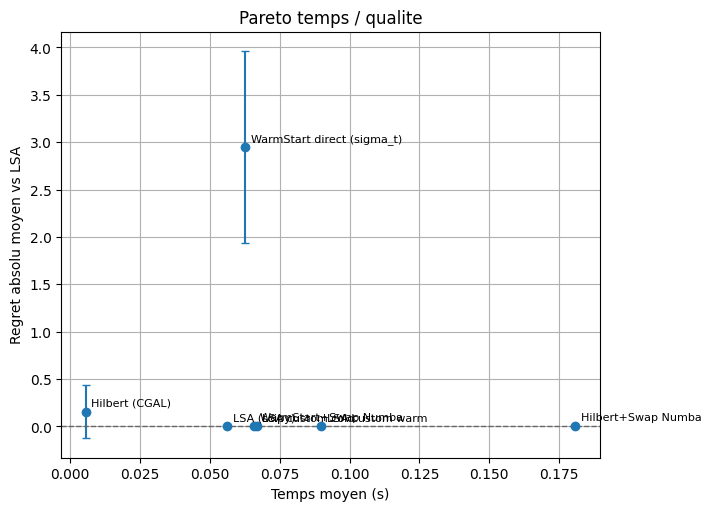

In [8]:
# ---- Pareto: temps vs regret ----
pareto = (
    df_summary[
        (df_summary["regime"] == "cold_full")
        & (df_summary["K"] == K_LIST[0])
        & (df_summary["N_particles"] == N_PARTICLES_LIST[0])
        & (df_summary["N_obs"] == N_OBS_LIST[0])
    ]
    .copy()
)

if len(pareto) == 0:
    print("Aucune donnee Pareto")
else:
    fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
    x = pareto["time_s_mean"].to_numpy()
    y = pareto["regret_abs_vs_lsa_mean"].to_numpy()
    yerr = pareto["regret_abs_vs_lsa_std"].fillna(0.0).to_numpy()

    ax.errorbar(x, y, yerr=yerr, fmt="o", capsize=3)
    for _, r in pareto.iterrows():
        ax.annotate(r["method_label"], (r["time_s_mean"], r["regret_abs_vs_lsa_mean"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

    ax.axhline(0.0, linestyle="--", color="0.4", linewidth=1.0)
    ax.set_xlabel("Temps moyen (s)")
    ax.set_ylabel("Regret absolu moyen vs LSA")
    ax.set_title("Pareto temps / qualite")
    plt.show()

/var/folders/bc/mlt2yzpn2hsg7qskk5s47jy40000gn/T/ipykernel_30984/1029628291.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


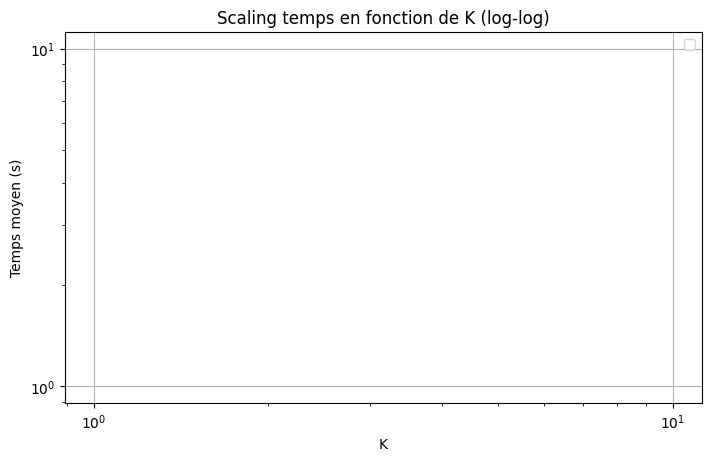

In [9]:
# ---- Scaling avec K (LSA vs Hilbert) ----
if len(K_LIST) < 2:
    print("Ajouter plusieurs valeurs de K pour le plot scaling")
else:
    sc = df_summary[
        (df_summary["regime"] == "cold_full")
        & (df_summary["N_particles"] == N_PARTICLES_LIST[0])
        & (df_summary["N_obs"] == N_OBS_LIST[0])
        & (df_summary["method_label"].isin(["LSA", "Hilbert", "Hilbert+Swap"]))
    ].copy()

    fig, ax = plt.subplots(figsize=(7, 4.5), layout="constrained")
    for m in ["LSA", "Hilbert", "Hilbert+Swap"]:
        sm = sc[sc["method_label"] == m].sort_values("K")
        if len(sm) > 0:
            ax.plot(sm["K"], sm["time_s_mean"], marker="o", label=m)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("K")
    ax.set_ylabel("Temps moyen (s)")
    ax.set_title("Scaling temps en fonction de K (log-log)")
    ax.legend()
    plt.show()

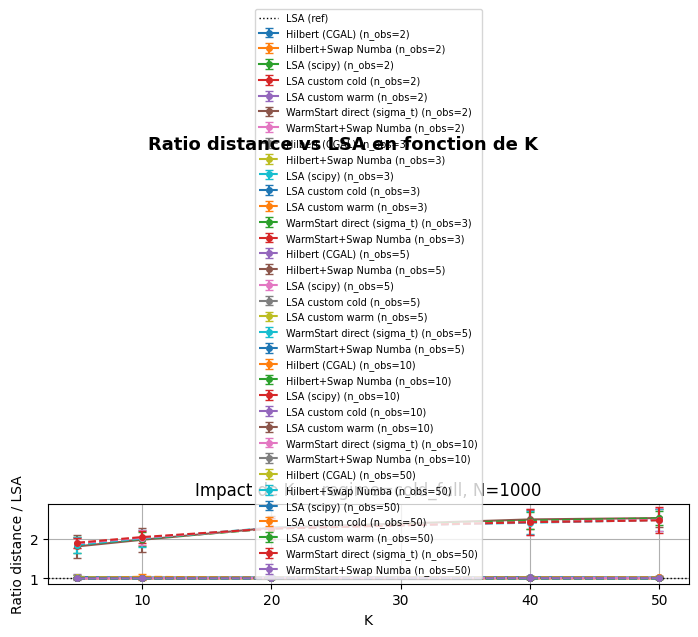

In [10]:
# ---- Plot: impact de K sur le ratio distance vs LSA ----
if len(K_LIST) < 2:
    print("Il faut au moins 2 valeurs de K pour ce plot.")
else:
    fig, axes = plt.subplots(1, len(REGIMES), figsize=(7 * len(REGIMES), 5), layout="constrained", sharey=True)
    if len(REGIMES) == 1:
        axes = [axes]

    plot_N = N_PARTICLES_LIST[0]

    for ax_idx, regime in enumerate(REGIMES):
        ax = axes[ax_idx]
        for n_obs in N_OBS_LIST:
            sub = df_summary[
                (df_summary["regime"] == regime)
                & (df_summary["N_particles"] == plot_N)
                & (df_summary["N_obs"] == n_obs)
                & (df_summary["method_label"] != "LSA")
            ].copy()

            methods = sub["method_label"].unique()
            for method in sorted(methods):
                sm = sub[sub["method_label"] == method].sort_values("K")
                if len(sm) == 0:
                    continue
                label = f"{method} (n_obs={n_obs})" if len(N_OBS_LIST) > 1 else method
                linestyle = "-" if n_obs == N_OBS_LIST[0] else "--"
                ax.errorbar(
                    sm["K"], sm["distance_ratio_vs_lsa_mean"],
                    yerr=sm["distance_ratio_vs_lsa_std"].fillna(0),
                    marker="o", markersize=4, capsize=3, linestyle=linestyle, label=label,
                )

        ax.axhline(1.0, linestyle=":", color="black", linewidth=1.0, label="LSA (ref)")
        ax.set_xlabel("K")
        if ax_idx == 0:
            ax.set_ylabel("Ratio distance / LSA")
        ax.set_title(f"Impact de K — regime={regime}, N={plot_N}")
        ax.legend(fontsize=7, loc="best")

    plt.suptitle("Ratio distance vs LSA en fonction de K", fontsize=13, fontweight="bold")
    plt.show()

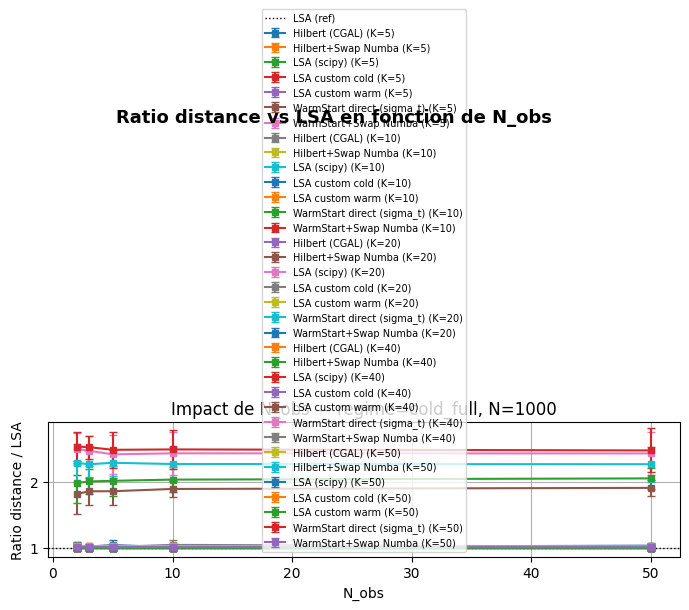

In [11]:
# ---- Plot: impact de N_obs sur le ratio distance vs LSA ----
if len(N_OBS_LIST) < 2:
    print("Il faut au moins 2 valeurs de N_obs pour ce plot.")
else:
    fig, axes = plt.subplots(1, len(REGIMES), figsize=(7 * len(REGIMES), 5), layout="constrained", sharey=True)
    if len(REGIMES) == 1:
        axes = [axes]

    plot_N = N_PARTICLES_LIST[0]

    for ax_idx, regime in enumerate(REGIMES):
        ax = axes[ax_idx]
        for K in K_LIST:
            sub = df_summary[
                (df_summary["regime"] == regime)
                & (df_summary["N_particles"] == plot_N)
                & (df_summary["K"] == K)
                & (df_summary["method_label"] != "LSA")
            ].copy()

            methods = sub["method_label"].unique()
            for method in sorted(methods):
                sm = sub[sub["method_label"] == method].sort_values("N_obs")
                if len(sm) == 0:
                    continue
                label = f"{method} (K={K})" if len(K_LIST) > 1 else method
                ax.errorbar(
                    sm["N_obs"], sm["distance_ratio_vs_lsa_mean"],
                    yerr=sm["distance_ratio_vs_lsa_std"].fillna(0),
                    marker="s", markersize=4, capsize=3, label=label,
                )

        ax.axhline(1.0, linestyle=":", color="black", linewidth=1.0, label="LSA (ref)")
        ax.set_xlabel("N_obs")
        if ax_idx == 0:
            ax.set_ylabel("Ratio distance / LSA")
        ax.set_title(f"Impact de N_obs — regime={regime}, N={plot_N}")
        ax.legend(fontsize=7, loc="best")

    plt.suptitle("Ratio distance vs LSA en fonction de N_obs", fontsize=13, fontweight="bold")
    plt.show()

/var/folders/bc/mlt2yzpn2hsg7qskk5s47jy40000gn/T/ipykernel_30984/1801803519.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(methods))


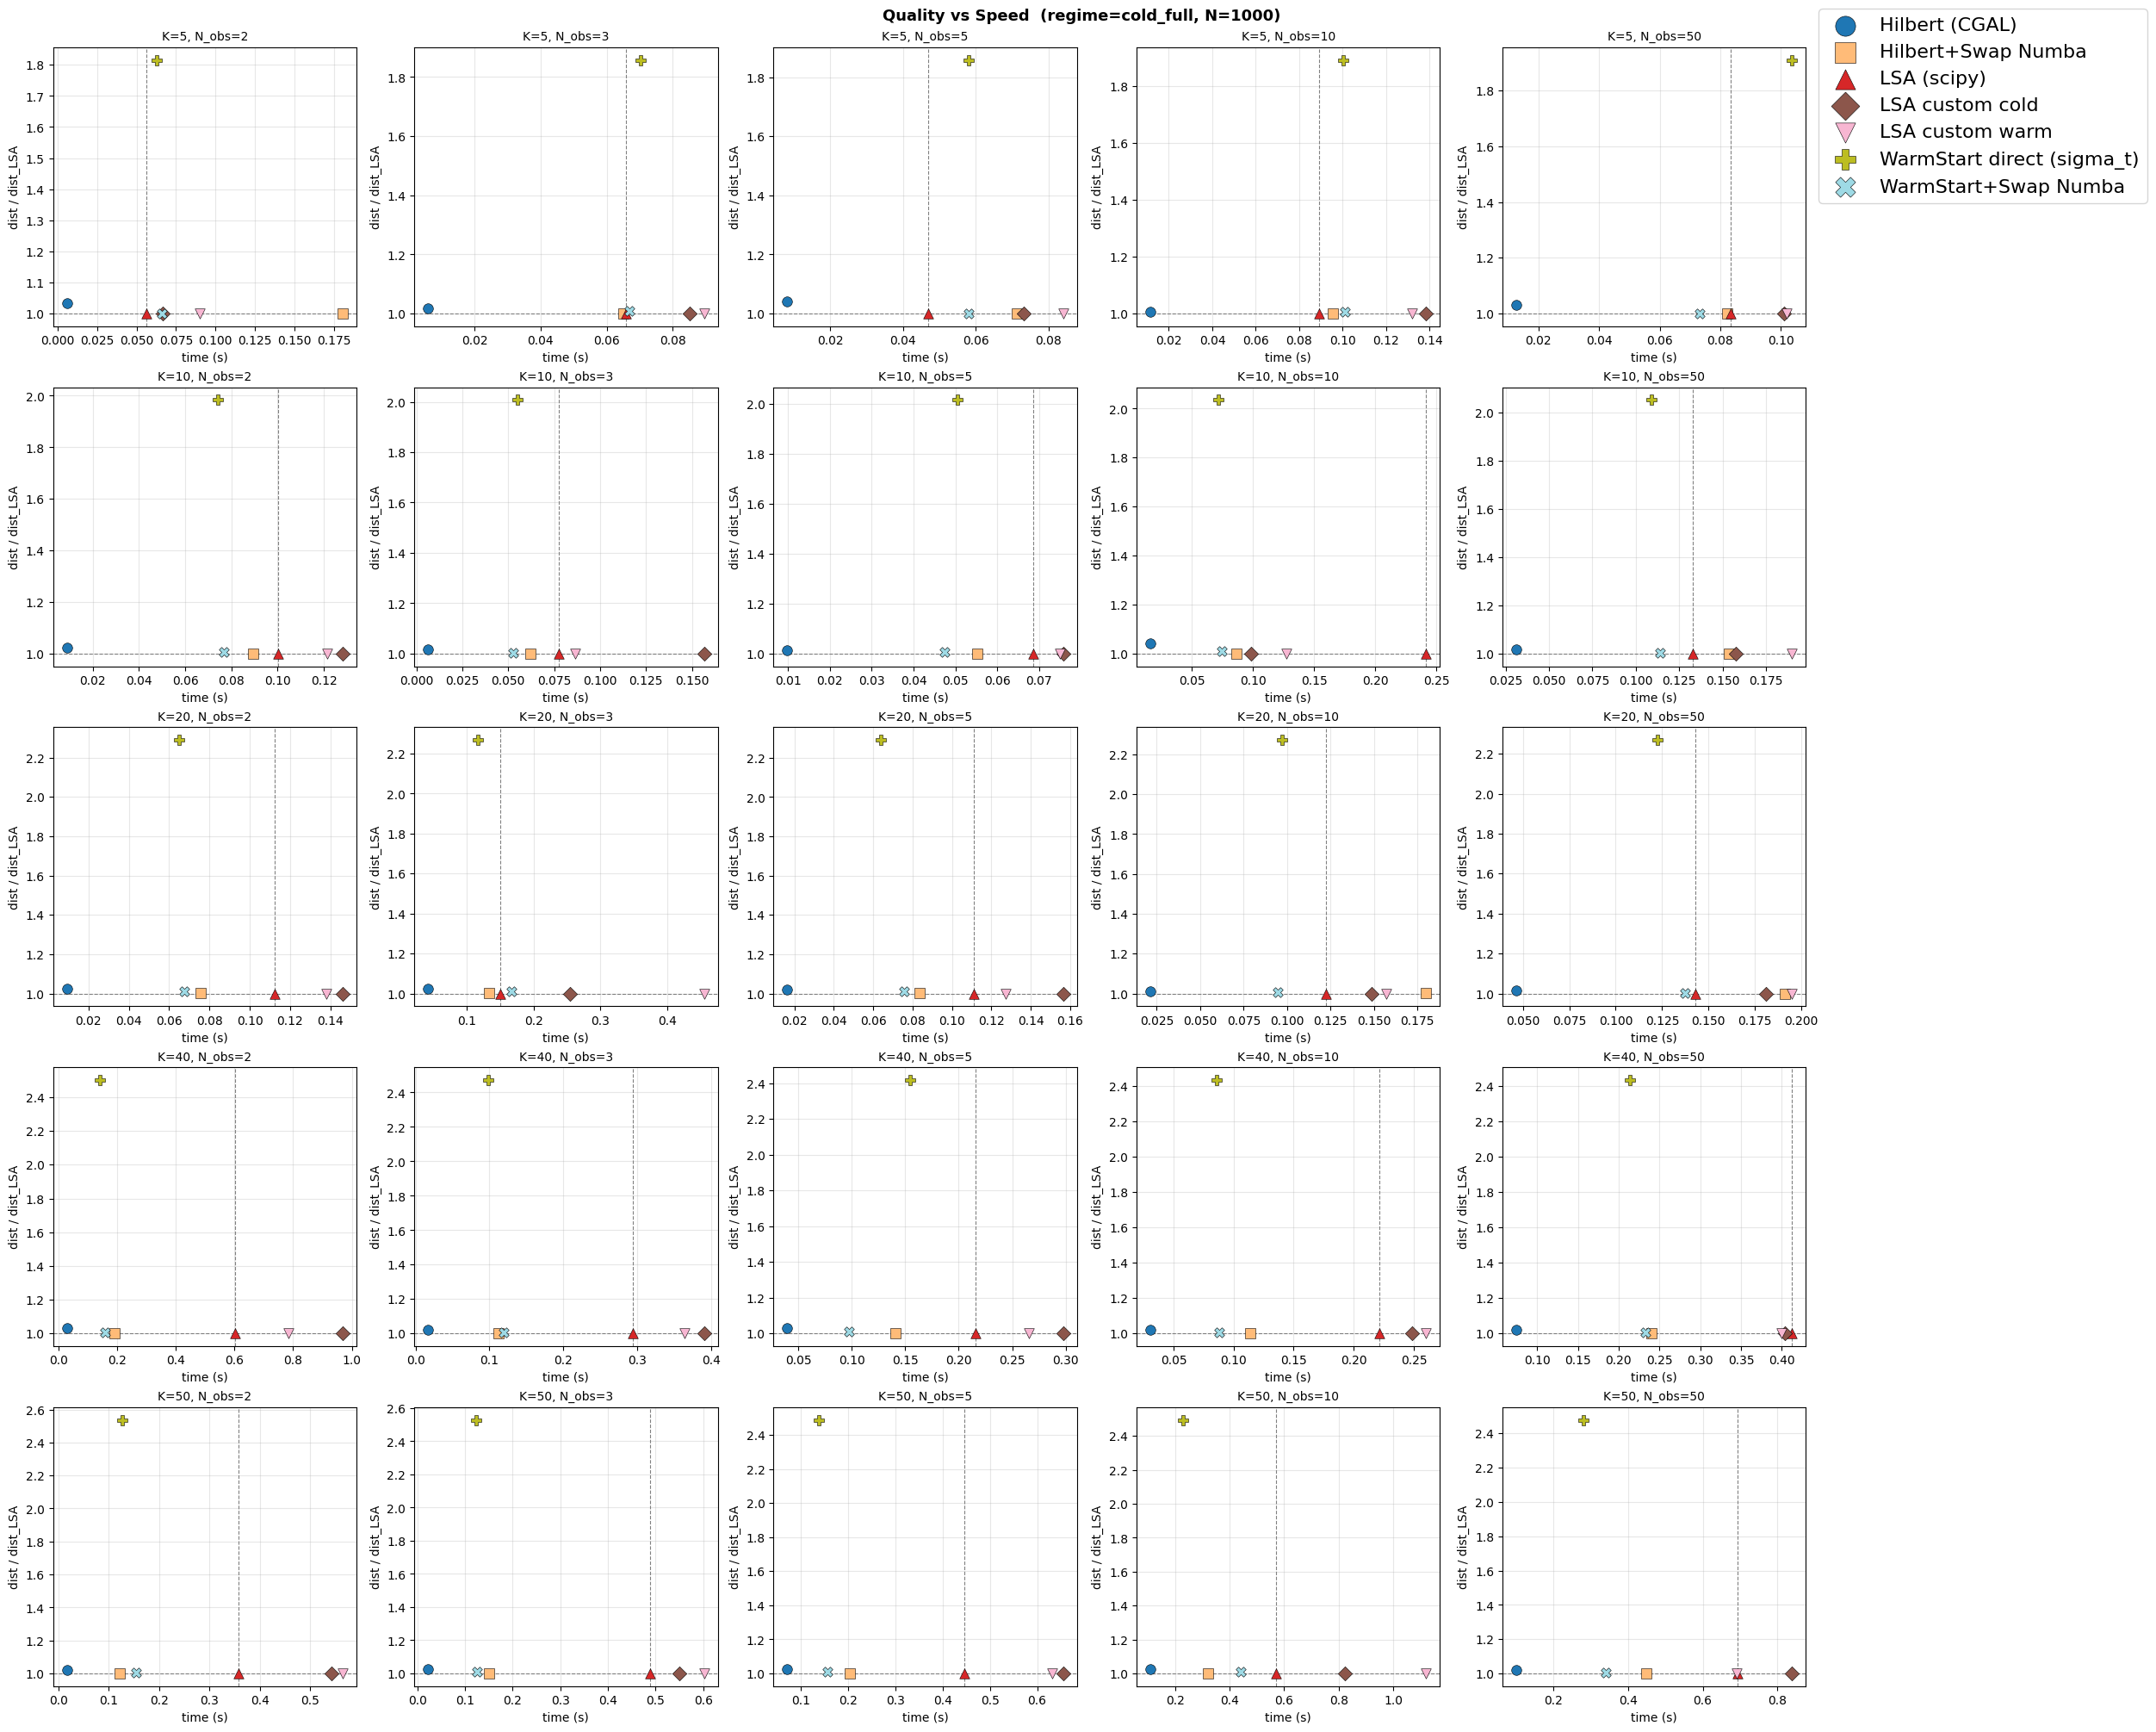

In [13]:
# ---- Plot: dist/dist_LSA vs time (scatter, one subplot per K x N_obs) ----
_regime = "cold_full"
_N = N_PARTICLES_LIST[0]

sub_all = df_summary[
    (df_summary["regime"] == _regime)
    & (df_summary["N_particles"] == _N)
].copy()

if sub_all.empty:
    print("Aucune donnée pour ce filtre")
else:
    ks = sorted(sub_all["K"].unique())
    nobs_list = sorted(sub_all["N_obs"].unique())
    n_rows, n_cols = len(ks), len(nobs_list)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        squeeze=False,
        layout="constrained",
    )

    methods = sorted(sub_all["method_label"].unique())
    cmap = plt.cm.get_cmap("tab20", len(methods))
    color_map = {m: cmap(i) for i, m in enumerate(methods)}
    marker_list = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "<", ">", "p", "H", "d"]
    marker_map = {m: marker_list[i % len(marker_list)] for i, m in enumerate(methods)}

    for ri, K in enumerate(ks):
        for ci, nobs in enumerate(nobs_list):
            ax = axes[ri][ci]
            chunk = sub_all[(sub_all["K"] == K) & (sub_all["N_obs"] == nobs)]
            for _, row in chunk.iterrows():
                label = row["method_label"]
                ax.scatter(
                    row["time_s_mean"],
                    row["distance_ratio_vs_lsa_mean"],
                    color=color_map[label],
                    marker=marker_map[label],
                    s=70,
                    edgecolors="k",
                    linewidths=0.4,
                    zorder=3,
                    label=label,
                )
                if label =='LSA (scipy)':
                    ax.axvline(row["time_s_mean"], color="grey", ls="--", lw=0.8, zorder=1)
            ax.axhline(1.0, color="grey", ls="--", lw=0.8, zorder=1)
            ax.set_xlabel("time (s)")
            ax.set_ylabel("dist / dist_LSA")
            ax.set_title(f"K={K}, N_obs={nobs}", fontsize=10)
            ax.grid(True, alpha=0.3)

    # shared legend
    handles, labels_ = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="outside right upper", fontsize=16, markerscale=2.0)
    fig.suptitle(
        f"Quality vs Speed  (regime={_regime}, N={_N})",
        fontsize=13,
        fontweight="bold",
    )
    plt.show()